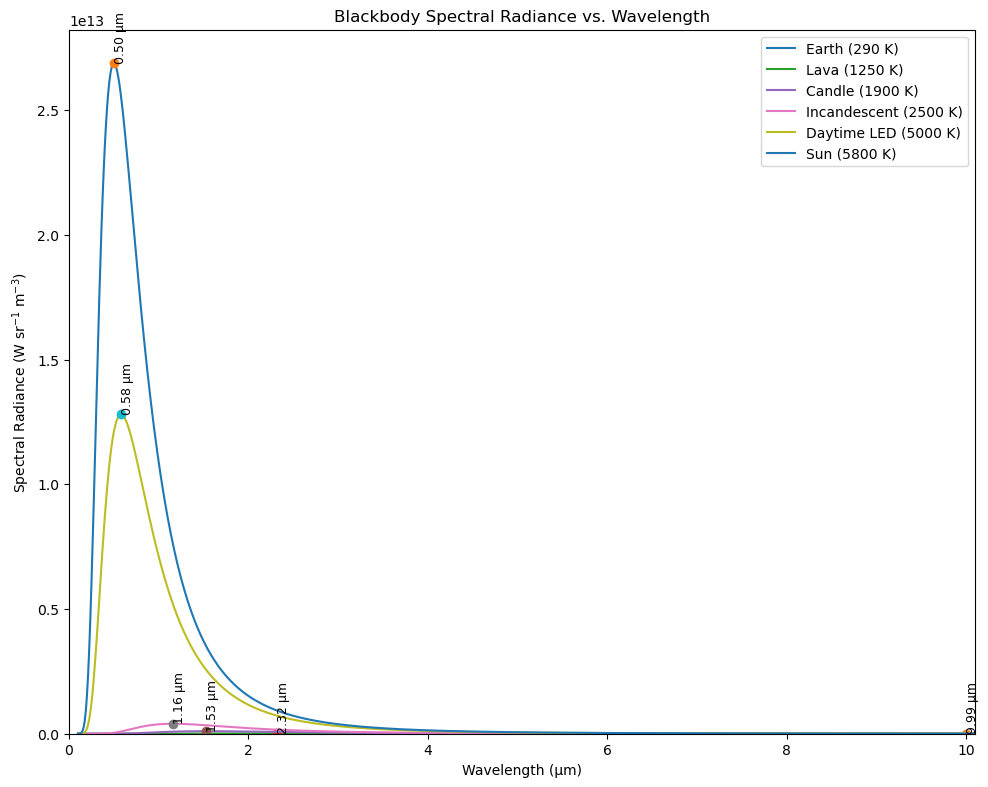

In [8]:
# Blackbody spectral radiance with Wien's Displacement Law peak labels

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Physical constants (SI)
# ----------------------------
h = 6.62607015e-34        # Planck constant (J·s)
c = 2.99792458e8         # Speed of light (m/s)
k = 1.380649e-23         # Boltzmann constant (J/K)
A = 2.898e-3             # Wien's displacement constant (m·K)

# ----------------------------
# Temperatures (K)
# ----------------------------
temps = {
    "Earth (290 K)": 290,
    "Lava (1250 K)": 1250,
    "Candle (1900 K)": 1900,
    "Incandescent (2500 K)": 2500,
    "Daytime LED (5000 K)": 5000,
    "Sun (5800 K)": 5800
}

# ----------------------------
# Wavelength range: 0–100 µm
# ----------------------------
wavelength = np.linspace(0.1e-6, 100e-6, 8000)  # meters

# ----------------------------
# Planck spectral radiance
# ----------------------------
def planck_law(wl, T):
    return (2 * h * c**2 / wl**5) / (np.exp(h * c / (wl * k * T)) - 1)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 8))

for label, T in temps.items():
    B = planck_law(wavelength, T)
    plt.plot(wavelength * 1e6, B, label=label)

    # Wien's law peak
    wl_peak = A / T                 # meters
    wl_peak_um = wl_peak * 1e6      # microns
    B_peak = planck_law(wl_peak, T)

    # Mark and label peak (on-plot only)
    plt.plot(wl_peak_um, B_peak, 'o')
    plt.text(wl_peak_um, B_peak,
             f"{wl_peak_um:.2f} µm",
             fontsize=9,
             ha='left',
             va='bottom',
             rotation=90)

# ----------------------------
# Formatting
# ----------------------------
plt.xlabel("Wavelength (µm)")
plt.ylabel("Spectral Radiance (W sr$^{-1}$ m$^{-3}$)")
plt.title("Blackbody Spectral Radiance vs. Wavelength")
plt.xlim(0, 10.1)
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()

plt.show()
